In [4]:
import subprocess
subprocess.check_call(["pip", "install", "xgboost"])

0

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import joblib
import os
 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
    f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline
 
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

In [7]:
df = pd.read_csv('../data/cleaned_data/clustered.csv')
df.head()

,Source,Air_Temperature,Process_Temp,Rotational_Speed,Torque,Life_Consumed,Stress_Index,RUL,Is_Failure,Health_Status,PC1,PC2,PC3,Cluster,Health_Regime
0,AI4I,299.228419,306.899157,1559.219588,43.187703,0,0.470538,50,0,Warning,-2.405392,-1.563244,0.621225,2,Critical
1,AI4I,296.759079,307.729191,1405.990381,46.889688,3,0.505412,49,0,Warning,-2.423106,-1.484609,1.261330,2,Critical
2,AI4I,298.018549,309.175868,1509.324445,49.237010,5,0.512735,48,0,Warning,-2.167529,-1.444552,1.488999,2,Critical
3,AI4I,299.183173,308.553352,1425.993973,39.545599,7,0.478745,47,0,Warning,-2.755876,-1.477009,0.234226,2,Critical
4,AI4I,300.709087,308.954130,1400.229355,40.097456,9,0.485819,46,0,Warning,-2.755291,-1.442209,0.329675,2,Critical


In [9]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Null values: {df.isnull().sum().sum()}")
print(f"\nTarget distribution (Health_Status):")
print(df["Health_Status"].value_counts().to_string())

Shape: (30631, 15)
Columns: ['Source', 'Air_Temperature', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Life_Consumed', 'Stress_Index', 'RUL', 'Is_Failure', 'Health_Status', 'PC1', 'PC2', 'PC3', 'Cluster', 'Health_Regime']
Null values: 0

Target distribution (Health_Status):
Health_Status
Warning     21260
Critical     7962
Healthy      1409


# Feature Selection

In [10]:
FEATURES = ["PC1", "PC2", "PC3", "Cluster", "Stress_Index", "RUL"]
TARGET   = "Health_Status"   # 3-class: Healthy / Warning / Critical
 
X = df[FEATURES].copy()
y = df[TARGET].copy()
 
print(f"Features used: {FEATURES}")
print(f"Target: {TARGET}")
print(f"X shape: {X.shape}")
 

Features used: ['PC1', 'PC2', 'PC3', 'Cluster', 'Stress_Index', 'RUL']
Target: Health_Status
X shape: (30631, 6)


# Target Encoding

In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y) # Healthy=0, Warning=1, Critical=2
classes = le.classes_
 
print(f"Class mapping : {dict(zip(classes, le.transform(classes)))}")
 

Class mapping : {'Critical': np.int64(0), 'Healthy': np.int64(1), 'Warning': np.int64(2)}


# Data Splitting

In [13]:
X_train, X_test, y_train, y_test = train_test_split( X, y_enc,test_size=0.20,random_state=42,stratify=y_enc  )    # keeps class proportions in both splits)
 
print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"Train class dist: { dict(zip(*np.unique(y_train, return_counts=True))) }")
print(f"Test  class dist: { dict(zip(*np.unique(y_test,  return_counts=True))) }")

Train size: 24504
Test size: 6127
Train class dist: {np.int64(0): np.int64(6369), np.int64(1): np.int64(1127), np.int64(2): np.int64(17008)}
Test  class dist: {np.int64(0): np.int64(1593), np.int64(1): np.int64(282), np.int64(2): np.int64(4252)}


In [14]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)
 

# XGBOOST Model

In [16]:
xgb_model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder= False,
    eval_metric      = "mlogloss",
    random_state     = 42,
    n_jobs           = -1
)
 
xgb_model.fit(
    X_train, y_train,
    sample_weight = sample_weights_train,
    eval_set      = [(X_test, y_test)],
    verbose       = False
)
 
y_pred_xgb  = xgb_model.predict(X_test)
y_prob_xgb  = xgb_model.predict_proba(X_test)
 
xgb_acc    = accuracy_score(y_test, y_pred_xgb)
xgb_f1     = f1_score(y_test, y_pred_xgb, average="macro")
xgb_auc    = roc_auc_score(y_test, y_prob_xgb, multi_class="ovr", average="macro")
 
print(f"XGBoost  |  Accuracy: {xgb_acc:.4f}  |  F1-macro: {xgb_f1:.4f}  |  AUC-macro: {xgb_auc:.4f}")

XGBoost  |  Accuracy: 0.9860  |  F1-macro: 0.9831  |  AUC-macro: 0.9824


# SVM MODEL

In [17]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(
        kernel        = "rbf",
        C             = 10,
        gamma         = "scale",
        class_weight  = "balanced",   # handles imbalanced classes
        probability   = True,         # needed for predict_proba / AUC
        random_state  = 42
    ))
])
 
svm_pipeline.fit(X_train, y_train)
 
y_pred_svm  = svm_pipeline.predict(X_test)
y_prob_svm  = svm_pipeline.predict_proba(X_test)
 
svm_acc    = accuracy_score(y_test, y_pred_svm)
svm_f1     = f1_score(y_test, y_pred_svm, average="macro")
svm_auc    = roc_auc_score(y_test, y_prob_svm, multi_class="ovr", average="macro")
 
print(f"SVM      |  Accuracy: {svm_acc:.4f}  |  F1-macro: {svm_f1:.4f}  |  AUC-macro: {svm_auc:.4f}")
 

SVM      |  Accuracy: 0.9512  |  F1-macro: 0.9342  |  AUC-macro: 0.9853


# Cross Validation

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use only 20% of data for CV to make it faster
from sklearn.model_selection import train_test_split
X_cv, _, y_cv, _ = train_test_split(X, y_enc, train_size=0.2, random_state=42, stratify=y_enc)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = cross_val_score(xgb_model, X_cv, y_cv, cv=cv, scoring="f1_macro", n_jobs=-1)
svm_cv = cross_val_score(svm_pipeline, X_cv, y_cv, cv=cv, scoring="f1_macro", n_jobs=-1)

print(f"XGBoost CV F1-macro : {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f} | Folds: {np.round(xgb_cv, 4)}")
print(f"SVM     CV F1-macro : {svm_cv.mean():.4f} ± {svm_cv.std():.4f} | Folds: {np.round(svm_cv, 4)}")

XGBoost CV F1-macro : 0.9867 ± 0.0037 | Folds: [0.9875 0.992  0.9868 0.987  0.9803]
SVM     CV F1-macro : 0.9236 ± 0.0084 | Folds: [0.9138 0.9313 0.9281 0.9318 0.9129]


# Classification Reports

In [19]:
print("\n--- XGBoost ---")
print(classification_report(y_test, y_pred_xgb, target_names=classes))
 
print("--- SVM ---")
print(classification_report(y_test, y_pred_svm, target_names=classes))


--- XGBoost ---
              precision    recall  f1-score   support

    Critical       1.00      0.95      0.97      1593
     Healthy       0.97      1.00      0.99       282
     Warning       0.98      1.00      0.99      4252

    accuracy                           0.99      6127
   macro avg       0.98      0.98      0.98      6127
weighted avg       0.99      0.99      0.99      6127

--- SVM ---
              precision    recall  f1-score   support

    Critical       0.90      0.95      0.92      1593
     Healthy       0.84      1.00      0.92       282
     Warning       0.98      0.95      0.97      4252

    accuracy                           0.95      6127
   macro avg       0.91      0.97      0.93      6127
weighted avg       0.95      0.95      0.95      6127



# Visualisation

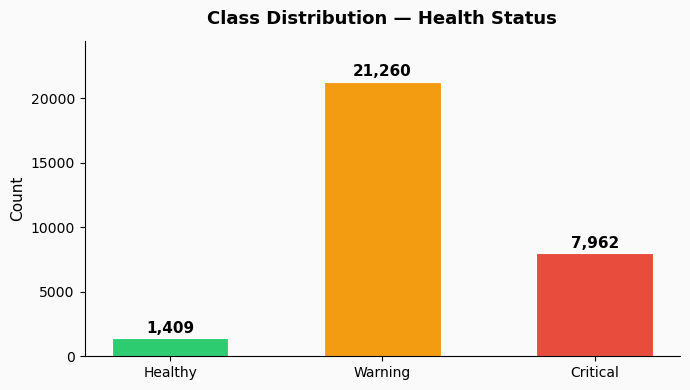

In [23]:
palette = {"Healthy": "#2ecc71", "Warning": "#f39c12", "Critical": "#e74c3c"}
fig_bg  = "#FAFAFA"
 
 
# ── Plot 1: Class Distribution ─────────────────
fig, ax = plt.subplots(figsize=(7, 4), facecolor=fig_bg)
counts = df[TARGET].value_counts().reindex(["Healthy", "Warning", "Critical"])
bars = ax.bar(counts.index, counts.values,
              color=[palette[c] for c in counts.index],
              edgecolor="white", linewidth=0.8, width=0.55)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Class Distribution — Health Status", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Count", fontsize=11)
ax.set_ylim(0, counts.max() * 1.15)
ax.set_facecolor(fig_bg)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

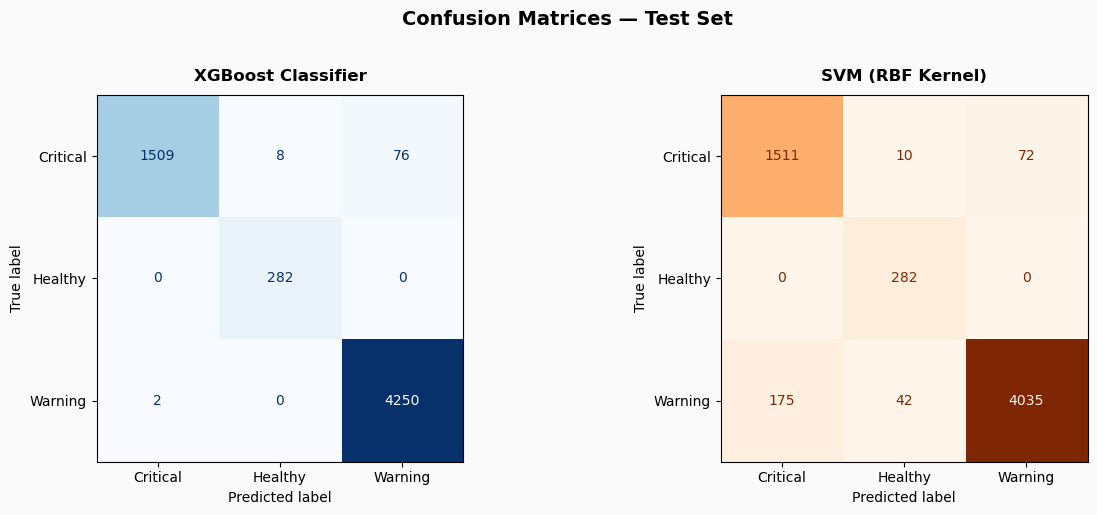

In [24]:
# ── Plot 2: Confusion Matrices (side by side) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=fig_bg)
for ax, y_pred, title, cmap in zip(
        axes,
        [y_pred_xgb, y_pred_svm],
        ["XGBoost Classifier", "SVM (RBF Kernel)"],
        ["Blues", "Oranges"]):
 
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_facecolor(fig_bg)
 
fig.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/02_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

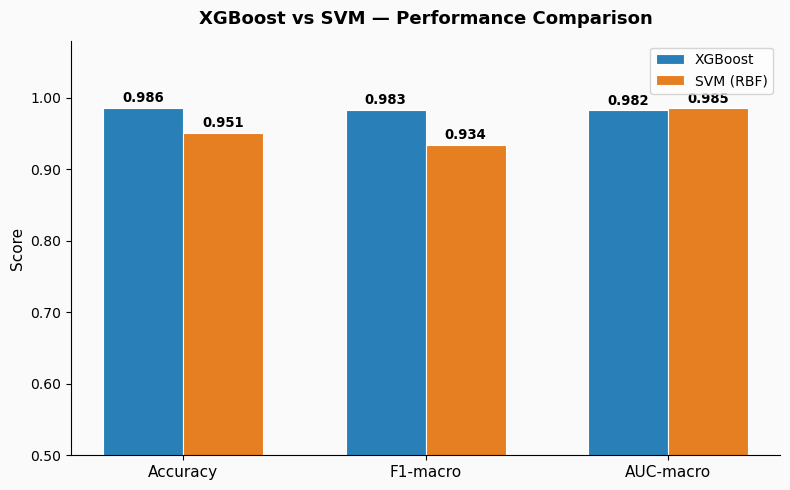

In [25]:
# ── Plot 3: Model Comparison Bar Chart ──────────
metrics     = ["Accuracy", "F1-macro", "AUC-macro"]
xgb_scores  = [xgb_acc, xgb_f1, xgb_auc]
svm_scores  = [svm_acc, svm_f1, svm_auc]
 
x   = np.arange(len(metrics))
w   = 0.33
fig, ax = plt.subplots(figsize=(8, 5), facecolor=fig_bg)
 
b1 = ax.bar(x - w/2, xgb_scores, width=w, label="XGBoost",
            color="#2980b9", edgecolor="white", linewidth=0.8)
b2 = ax.bar(x + w/2, svm_scores, width=w, label="SVM (RBF)",
            color="#e67e22", edgecolor="white", linewidth=0.8)
 
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f"{h:.3f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
 
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.08)
ax.set_title("XGBoost vs SVM — Performance Comparison", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Score", fontsize=11)
ax.legend(fontsize=10)
ax.set_facecolor(fig_bg)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.savefig("outputs/03_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 

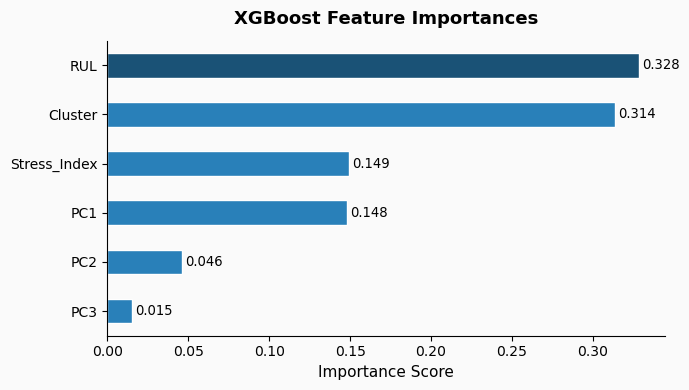

In [26]:
# ── Plot 4: XGBoost Feature Importance ─────────
fig, ax = plt.subplots(figsize=(7, 4), facecolor=fig_bg)
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
colors = ["#2980b9" if v < importances.max() else "#1a5276" for v in importances]
importances.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("XGBoost Feature Importances", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_facecolor(fig_bg)
ax.spines[["top","right"]].set_visible(False)
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9.5)
plt.tight_layout()
plt.savefig("outputs/04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
 

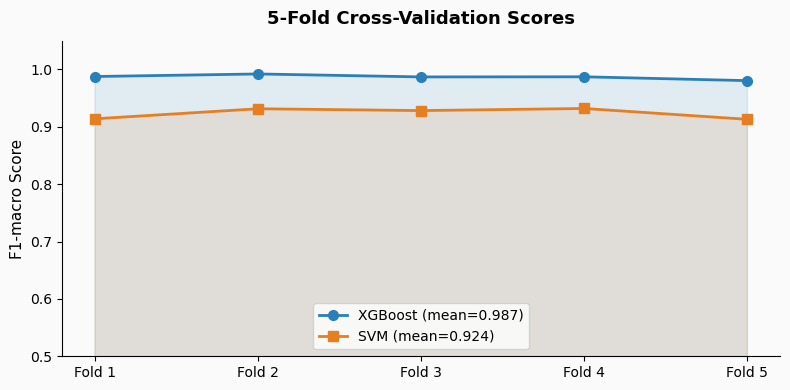

In [29]:
# ── Plot 5: CV Score Distribution ───────────────
fig, ax = plt.subplots(figsize=(8, 4), facecolor=fig_bg)
fold_labels = [f"Fold {i+1}" for i in range(5)]
x = np.arange(5)
ax.plot(x, xgb_cv, "o-", color="#2980b9", linewidth=2, markersize=7, label=f"XGBoost (mean={xgb_cv.mean():.3f})")
ax.plot(x, svm_cv, "s-", color="#e67e22", linewidth=2, markersize=7, label=f"SVM (mean={svm_cv.mean():.3f})")
ax.fill_between(x, xgb_cv, alpha=0.12, color="#2980b9")
ax.fill_between(x, svm_cv, alpha=0.12, color="#e67e22")
ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("F1-macro Score", fontsize=11)
ax.set_title("5-Fold Cross-Validation Scores", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10)
ax.set_facecolor(fig_bg)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/05_cv_scores.png", dpi=150, bbox_inches="tight")
plt.show()
 

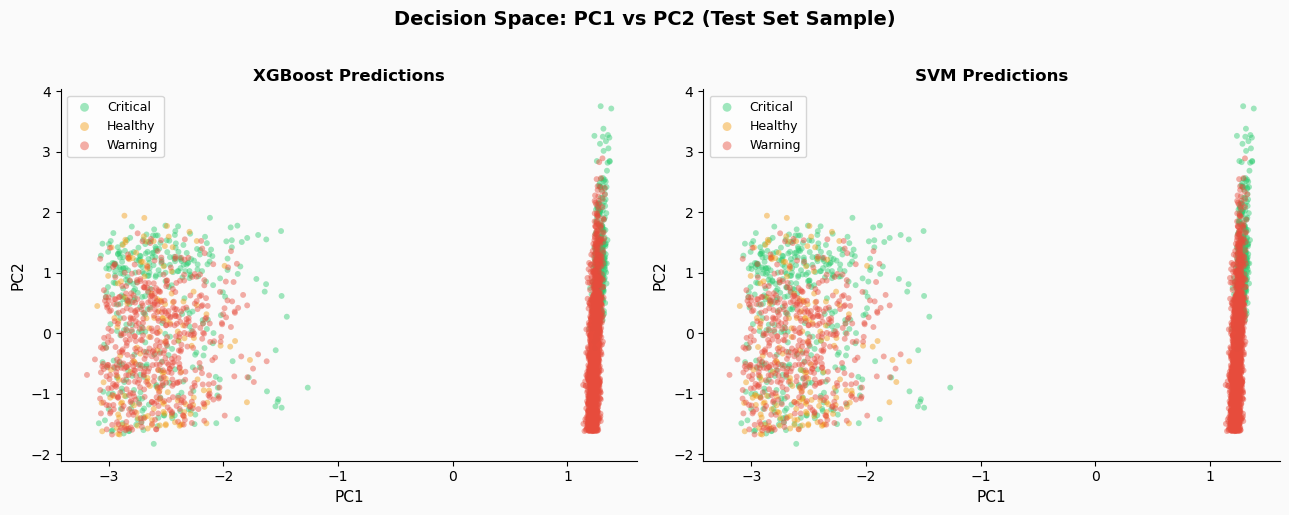

In [30]:
# ── Plot 6: PC1 vs PC2 coloured by prediction ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=fig_bg)
color_map = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
label_map  = {i: c for i, c in enumerate(classes)}
 
sample_idx = np.random.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_test_np  = X_test.to_numpy()
 
for ax, preds, title in zip(
        axes,
        [y_pred_xgb, y_pred_svm],
        ["XGBoost Predictions", "SVM Predictions"]):
 
    for cls_idx, cls_name in label_map.items():
        mask = preds[sample_idx] == cls_idx
        ax.scatter(
            X_test_np[sample_idx][mask, 0],
            X_test_np[sample_idx][mask, 1],
            c=color_map[cls_idx], label=cls_name,
            alpha=0.45, s=18, edgecolors="none"
        )
    ax.set_xlabel("PC1", fontsize=11)
    ax.set_ylabel("PC2", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, markerscale=1.5)
    ax.set_facecolor(fig_bg)
    ax.spines[["top","right"]].set_visible(False)
 
fig.suptitle("Decision Space: PC1 vs PC2 (Test Set Sample)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/06_pc_decision_space.png", dpi=150, bbox_inches="tight")
plt.show()

# Saving Models

In [32]:
joblib.dump(xgb_model,    "outputs/xgb_classifier.pkl")
joblib.dump(svm_pipeline, "outputs/svm_pipeline.pkl")
joblib.dump(le,           "outputs/label_encoder.pkl")
 
print("Saved: xgb_classifier.pkl")
print("Saved: svm_pipeline.pkl")
print("Saved: label_encoder.pkl")

Saved: xgb_classifier.pkl
Saved: svm_pipeline.pkl
Saved: label_encoder.pkl


# Final result

In [33]:
print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)
 
summary = pd.DataFrame({
    "Model"       : ["XGBoost", "SVM (RBF)"],
    "Accuracy"    : [round(xgb_acc, 4), round(svm_acc, 4)],
    "F1-macro"    : [round(xgb_f1,  4), round(svm_f1,  4)],
    "AUC-macro"   : [round(xgb_auc, 4), round(svm_auc, 4)],
    "CV F1 mean"  : [round(xgb_cv.mean(), 4), round(svm_cv.mean(), 4)],
    "CV F1 std"   : [round(xgb_cv.std(),  4), round(svm_cv.std(),  4)],
})
print(summary.to_string(index=False))
 
winner = "XGBoost" if xgb_f1 >= svm_f1 else "SVM (RBF)"
print(f"\n  Best model by F1-macro: {winner}")
print("=" * 60)


  FINAL RESULTS SUMMARY
    Model  Accuracy  F1-macro  AUC-macro  CV F1 mean  CV F1 std
  XGBoost    0.9860    0.9831     0.9824      0.9867     0.0037
SVM (RBF)    0.9512    0.9342     0.9853      0.9236     0.0084

  Best model by F1-macro: XGBoost
